# Machine Translation - Transformers

Using the tutorial of NLP of keras for machine translation with transformers, we implemented a basic model for [Spanish to English translation](https://keras.io/examples/nlp/neural_machine_translation_with_transformer/).

In [1]:
# We set the backend to TensorFlow. The code works with
# both `tensorflow` and `torch`. It does not work with JAX
# due to the behavior of `jax.numpy.tile` in a jit scope
# (used in `TransformerDecoder.get_causal_attention_mask()`:
# `tile` in JAX does not support a dynamic `reps` argument.
# You can make the code work in JAX by wrapping the
# inside of the `get_causal_attention_mask` method in
# a decorator to prevent jit compilation:
# `with jax.ensure_compile_time_eval():`.
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import pathlib
import random
import string
import re
import numpy as np

import tensorflow.data as tf_data
import tensorflow.strings as tf_strings
import tensorflow as tf

import keras
from keras import layers
from keras import ops
from keras.layers import TextVectorization

I0000 00:00:1776778652.517705  117394 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776778652.566166  117394 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776778654.384653  117394 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Download the dataset

We will download the spa-eng dataset, which is a collection of Spanish-English sentence pairs.

In [2]:
text_file = keras.utils.get_file(
    fname="spa-eng.zip",
    origin="http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip",
    extract=True,
)
text_file = pathlib.Path(text_file) / "spa-eng" / "spa.txt"

## Parsing and preparing the dataset

In each line you have an English sentence and a Spanish sentence, separated by a tab. We will parse the dataset and prepare it for training. We also add two tokens: `[start]` and `[end]` to the English sentences.

In [3]:
with open(text_file, encoding='utf-8') as f:
    lines = f.read().split("\n")[:-1]
text_pairs = []
for line in lines:
    eng, spa = line.split("\t")
    eng = "[start] " + eng + " [end]"
    text_pairs.append((spa, eng))

for _ in range(5):
    print(random.choice(text_pairs))

('Esto es difícil para ti, ¿verdad?', "[start] This is hard for you, isn't it? [end]")
('Vamos a ir a comer el viernes.', "[start] We're going out for a meal on Friday. [end]")
('Lo siento, se me olvidó.', '[start] Sorry, I forgot. [end]')
('Quizá fui estúpida al creer que Tom realmente nos ayudaría.', '[start] Maybe it was stupid of me to think that Tom would really help us. [end]')
('¿Tom siente lo mismo?', '[start] Does Tom feel the same way? [end]')


## Dividing the dataset into train/val/test sets

We will divide the dataset into train/val/test sets for training and evaluation.

In [4]:
random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pairs = text_pairs[:num_train_samples]
val_pairs = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_pairs = text_pairs[num_train_samples + num_val_samples :]

print(f"{len(text_pairs)} total pairs")
print(f"{len(train_pairs)} training pairs")
print(f"{len(val_pairs)} validation pairs")
print(f"{len(test_pairs)} test pairs")

118964 total pairs
83276 training pairs
17844 validation pairs
17844 test pairs


## Vectorizing the text data

We have to use `TextVectorization` layers to vectorize the text data, 2 separate layers are used for each language, and specific strip characters are defined.

In [5]:
strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

vocab_size = 15000
sequence_length = 20
batch_size = 64


def custom_standardization(input_string):
    lowercase = tf_strings.lower(input_string)
    return tf_strings.regex_replace(lowercase, "[%s]" % re.escape(strip_chars), "")


eng_vectorization = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)
spa_vectorization = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize=custom_standardization,
)

# All the English and Spanish texts from the training set, in separate lists
train_eng_texts = [pair[1] for pair in train_pairs]
train_spa_texts = [pair[0] for pair in train_pairs]

# Create the vocabulary for both English and Spanish text vectorization layers
eng_vectorization.adapt(train_eng_texts)
spa_vectorization.adapt(train_spa_texts)

E0000 00:00:1776778656.924218  117394 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Now we have to prepare the dataset for training.

In [6]:
def format_dataset(eng, spa):
    eng = eng_vectorization(eng)
    spa = spa_vectorization(spa)
    return (
        {
            "encoder_inputs": spa,
            "decoder_inputs": eng[:, :-1],
        },
        eng[:, 1:],
    )


def make_dataset(pairs):
    spa_texts, eng_texts = zip(*pairs)
    eng_texts = list(eng_texts)
    spa_texts = list(spa_texts)
    dataset = tf_data.Dataset.from_tensor_slices((eng_texts, spa_texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset)
    return dataset.cache().shuffle(2048).prefetch(16)


train_ds = make_dataset(train_pairs)
val_ds = make_dataset(val_pairs)

Testing our functions on a few examples, we can see that the vectorization is working as expected.

In [7]:
for inputs, targets in train_ds.take(1):
    print(f'inputs["encoder_inputs"].shape: {inputs["encoder_inputs"].shape}')
    print(f'inputs["decoder_inputs"].shape: {inputs["decoder_inputs"].shape}')
    print(f"targets.shape: {targets.shape}")

inputs["encoder_inputs"].shape: (64, 20)
inputs["decoder_inputs"].shape: (64, 20)
targets.shape: (64, 20)


## Building the transformer model

Now we will build the transformer model for machine translation.

In [8]:
import keras.ops as ops


class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim: int, dense_dim: int, num_heads: int, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.dense_proj = keras.Sequential(
            [
                layers.Dense(dense_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.supports_masking = True

    def call(self, inputs, mask=None, return_attention_scores=False):
        if mask is not None:
            padding_mask = ops.cast(mask[:, None, :], dtype="int32")
        else:
            padding_mask = None

        if return_attention_scores:
            attention_output, attention_scores = self.attention(
                query=inputs,
                value=inputs,
                key=inputs,
                attention_mask=padding_mask,
                return_attention_scores=True,
            )
        else: 
            attention_output = self.attention(
                query=inputs, value=inputs, key=inputs, attention_mask=padding_mask
            )

        # input residual and attention_output added together and normalized
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)

        # residual proj_input and FFN output added together and normalized
        final_output = self.layernorm_2(proj_input + proj_output)

        # If attention scored are needed, return them. Else only return the final output
        if return_attention_scores:
            return final_output, attention_scores
        return final_output

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "embed_dim": self.embed_dim,
                "dense_dim": self.dense_dim,
                "num_heads": self.num_heads,
            }
        )
        return config


class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=embed_dim
        )
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def call(self, inputs):
        length = ops.shape(inputs)[-1]
        positions = ops.arange(0, length, 1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        # The meaning of the token + The positionnal information
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        return ops.not_equal(inputs, 0)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "sequence_length": self.sequence_length,
                "vocab_size": self.vocab_size,
                "embed_dim": self.embed_dim,
            }
        )
        return config


class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, latent_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.latent_dim = latent_dim
        self.num_heads = num_heads
        self.supports_masking = True

        self.attention_1 = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim,
            name="self_attention",
        )
        self.attention_2 = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim,
            name="cross_attention",
        )
        self.dense_proj = keras.Sequential(
            [
                layers.Dense(latent_dim, activation="relu"),
                layers.Dense(embed_dim),
            ],
            name="dense_proj",
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()

    def build(self, input_shape):
        # input_shape should be [decoder_shape, encoder_shape]
        decoder_shape = input_shape[0]
        encoder_shape = input_shape[1]

        self.attention_1.build(decoder_shape, decoder_shape, decoder_shape)
        self.attention_2.build(decoder_shape, encoder_shape, encoder_shape)
        self.dense_proj.build(decoder_shape)
        self.layernorm_1.build(decoder_shape)
        self.layernorm_2.build(decoder_shape)
        self.layernorm_3.build(decoder_shape)

        super().build(input_shape)

    def call(self, inputs, mask=None):
        decoder_inputs = inputs[0]
        encoder_outputs = inputs[1]

        causal_mask = self.get_causal_attention_mask(decoder_inputs)

        decoder_padding_mask = None
        encoder_padding_mask = None

        if mask is not None:
            if isinstance(mask, (list, tuple)):
                if len(mask) > 0:
                    decoder_padding_mask = mask[0]
                if len(mask) > 1:
                    encoder_padding_mask = mask[1]
            else:
                decoder_padding_mask = mask

        attn_output_1 = self.attention_1(
            query=decoder_inputs,
            value=decoder_inputs,
            key=decoder_inputs,
            attention_mask=causal_mask,
            query_mask=decoder_padding_mask,
            value_mask=decoder_padding_mask,
            key_mask=decoder_padding_mask,
        )
        out_1 = self.layernorm_1(decoder_inputs + attn_output_1)

        attn_output_2 = self.attention_2(
            query=out_1,
            value=encoder_outputs,
            key=encoder_outputs,
            query_mask=decoder_padding_mask,
            value_mask=encoder_padding_mask,
            key_mask=encoder_padding_mask,
        )
        out_2 = self.layernorm_2(out_1 + attn_output_2)

        proj_output = self.dense_proj(out_2)
        return self.layernorm_3(out_2 + proj_output)

    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size = input_shape[0]
        seq_len = input_shape[1]

        i = tf.range(seq_len)[:, None]
        j = tf.range(seq_len)[None, :]
        mask = tf.cast(i >= j, dtype=tf.bool)

        mask = tf.expand_dims(mask, axis=0)
        mask = tf.broadcast_to(mask, [batch_size, seq_len, seq_len])
        return mask

    def compute_output_shape(self, input_shape):
        return input_shape[0]

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "embed_dim": self.embed_dim,
                "latent_dim": self.latent_dim,
                "num_heads": self.num_heads,
            }
        )
        return config

Assembling our model together to have a full Transformer model.

In [9]:
embed_dim = 256
latent_dim = 2048
num_heads = 8

encoder_inputs = keras.Input(shape=(None,), dtype="int64", name="encoder_inputs")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(encoder_inputs)
encoder_outputs = TransformerEncoder(embed_dim, latent_dim, num_heads)(x)

decoder_inputs = keras.Input(shape=(None,), dtype="int64", name="decoder_inputs")
encoded_seq_inputs = keras.Input(shape=(None, embed_dim), name="decoder_state_inputs")

x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(decoder_inputs)
x = TransformerDecoder(embed_dim, latent_dim, num_heads)([x, encoded_seq_inputs])
x = layers.Dropout(0.5)(x)
decoder_outputs = layers.Dense(vocab_size, activation="softmax")(x)

decoder = keras.Model(
    [decoder_inputs, encoded_seq_inputs],
    decoder_outputs,
    name="decoder",
)

final_decoder_outputs = decoder([decoder_inputs, encoder_outputs])

transformer = keras.Model(
    {"encoder_inputs": encoder_inputs, "decoder_inputs": decoder_inputs},
    final_decoder_outputs,
    name="transformer",
)
transformer.load_weights('./best_model_spa_eng(2).keras')

/home/rahul25/.conda/envs/playground/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'decoder' (of type Functional) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


## Decoding test sentences

Here we are going to test on real world sentences, we will use the trained model to translate Spanish sentences to English.

In [10]:
spa_vocab = eng_vectorization.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))
max_decoded_sentence_length = 20


def decode_sequence(input_sentence):
    tokenized_input_sentence = spa_vectorization([input_sentence])
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        tokenized_target_sentence = eng_vectorization([decoded_sentence])[:, :-1]

        predictions = transformer(
            {
                "encoder_inputs": tokenized_input_sentence,
                "decoder_inputs": tokenized_target_sentence,
            }
        )

        sampled_token_index = ops.convert_to_numpy(
            ops.argmax(predictions[0, i, :])
        ).item(0)
        sampled_token = spa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token

        if sampled_token == "[end]":
            break
    return decoded_sentence


test_eng_texts = [pair[0] for pair in test_pairs]
for _ in range(30):
    input_sentence = random.choice(test_eng_texts)
    translated = decode_sequence(input_sentence)
    print(f"{input_sentence} = {translated}")

Había una vez una hermosa princesa. = [start] a tried of the support an [end]
Tom está pensando en vender su casa. = [start] tom is going out in the many is at home [end]
Cuando conoces por primera vez a alguien, mantén una conversación amena. = [start] i some trying for you to try a second used at me [end]
Nosotras tres permaneceremos juntas. = [start] seen beautiful like to the read [end]
Veamos si eso funciona. = [start] there outstanding up he has to where you [end]
Tomás se lo está pasando bien. = [start] not a isnt of him [end]
Me gustaría oírte hablar más de ello. = [start] again like to painted more not the help [end]
A ella no le gusta el sushi. = [start] she has im which here her here [end]
Veré a mis amigos esta noche, pero mi hermana no verá a los suyos. = [start] spoken i all drink need tom that may he didnt or were long were he run [end]
Si Mary le dio una bofetada a Tom, estoy segura de que se lo merecía. = [start] they so police tom made a bought up for what not to ever

## Visualizing the attention weights

We will vizualize the attention weights through a heatmap to see which words the model is paying attention to when translating a sentence.

Plotting for sentence: ¿Te gustaría ir por una película mañana en la noche?


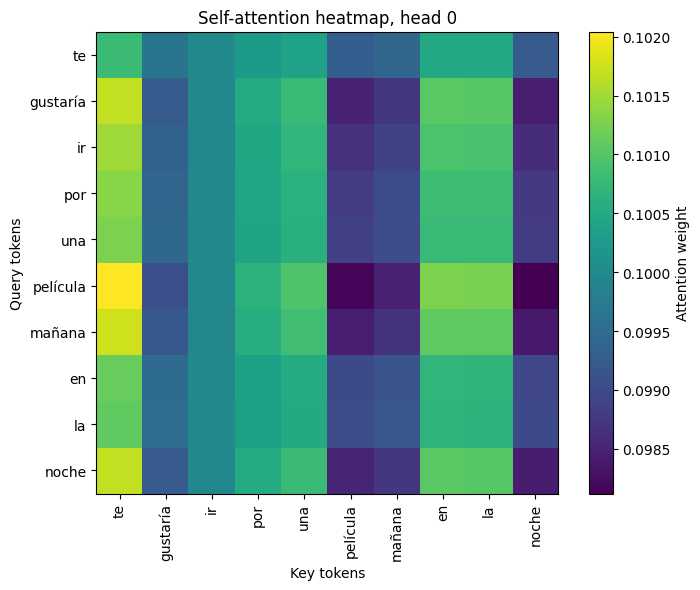

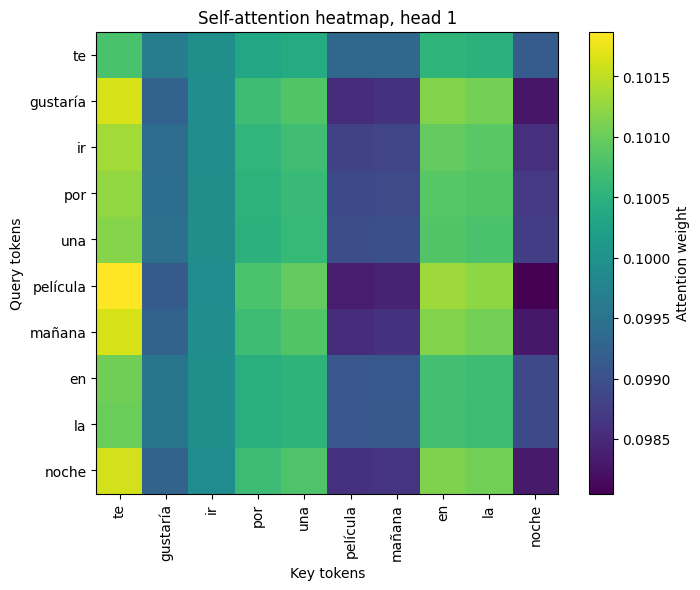

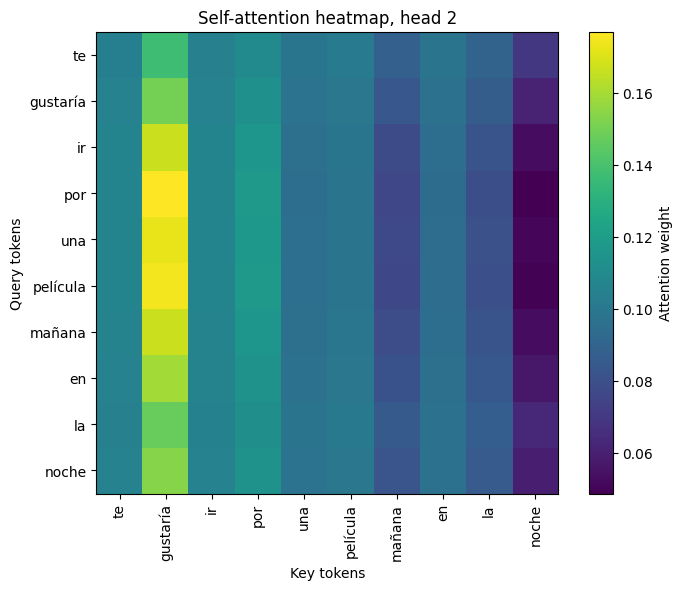

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention_heatmap(
    sample_sentence: str,
    heads: list[int] = [0],
):
    # Vectorize and add batch dimension
    tokenized_input = spa_vectorization([sample_sentence])

    # Extract layers
    pos_embed_layer = [l for l in transformer.layers if isinstance(l, PositionalEmbedding)][0]
    encoder_layer = [l for l in transformer.layers if isinstance(l, TransformerEncoder)][0]

    # Get embeddings
    embedded_inputs = pos_embed_layer(tokenized_input)

    # Create Padding mask
    padding_mask = ops.cast(ops.not_equal(tokenized_input, 0)[:, None, :], dtype="int32")

    # Extract attention scores
    _, attention_scores = encoder_layer(
        embedded_inputs, 
        mask=padding_mask[:, 0, :], 
        return_attention_scores=True
    )

    # Extract scores for the first head, shape: (1, num_heads, seq_len, seq_len)
    attention_scores = ops.convert_to_numpy(attention_scores)
    head_scores = [attention_scores[0, head, :, :] for head in heads]
    
    # Map vocabulary and filter out padding (0)
    actual_spa_vocab = spa_vectorization.get_vocabulary()
    actual_spa_lookup = dict(zip(range(len(actual_spa_vocab)), actual_spa_vocab))
    tokens = [actual_spa_lookup[t] for t in ops.convert_to_numpy(tokenized_input)[0] if t != 0]
    
    seq_len = len(tokens)
    for i in range(len(head_scores)):
        head_score = head_scores[i][:seq_len, :seq_len]

        # Plot
        fig, ax = plt.subplots(figsize=(8, 6))
        cax = ax.matshow(head_score, cmap='viridis')
        plt.colorbar(cax, label='Attention weight')

        # Setup Axes
        ax.set_xticks(range(seq_len))
        ax.set_xticklabels(tokens, rotation=90)
        ax.set_yticks(range(seq_len))
        ax.set_yticklabels(tokens)
        
        # Move x-axis labels completely to the bottom
        ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
        
        ax.set_xlabel('Key tokens')
        ax.set_ylabel('Query tokens')
        ax.set_title(f'Self-attention heatmap, head {i}')
        
        plt.show()

print(f"Plotting for sentence: {input_sentence}")
plot_attention_heatmap('', heads=[0, 1, 2])